**Data Loading & Inspection**

In [8]:
import pandas as pd

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshisatre/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshisatre/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [12]:
df=pd.read_csv("/kaggle/input/titanic-dataset/Titanic Dataset.csv")

In [13]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [14]:
df.tail()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3,0,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S,NaN,NaN,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [17]:
df.size

18326

In [18]:
df.shape

(1309, 14)

**Data Cleaning & Handling Missing Values**

In [19]:
print(df.isnull().sum())

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


In [24]:
df['age'] = df['age'].fillna(df['age'].median())

In [27]:
df['fare'] = df['fare'].fillna(df['fare'].median())

In [28]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [29]:
df = df.drop(columns=['cabin', 'boat', 'body', 'home.dest', 'ticket'])

In [30]:
print(df.isnull().sum())

pclass      0
survived    0
name        0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


**Univariate Visualizations (Histograms & Countplots)**

/tmp/ipykernel_844/399416700.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', palette='Set2')
/tmp/ipykernel_844/399416700.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pclass', palette='Set2')


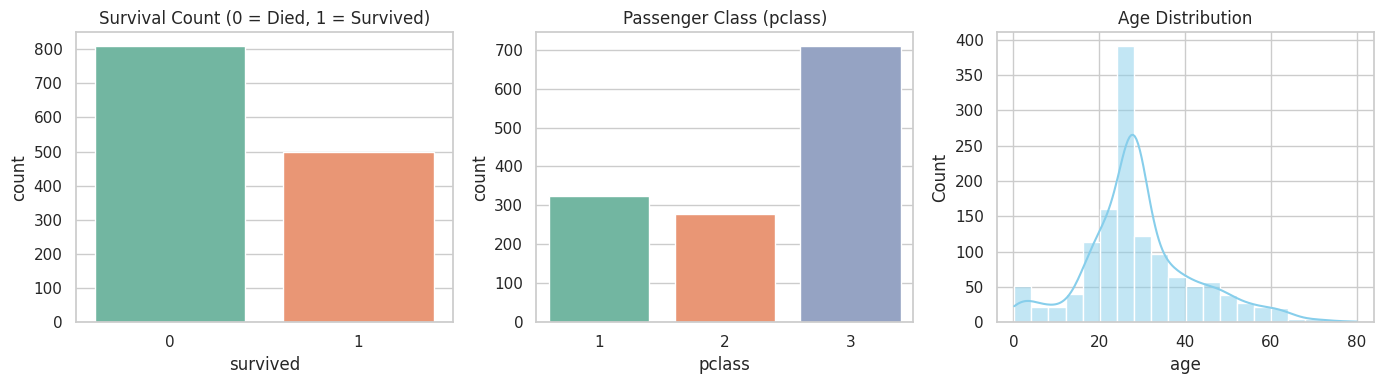

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 4))

# 1. Survival Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='survived', palette='Set2')
plt.title('Survival Count (0 = Died, 1 = Survived)')

# 2. Passenger Class Distribution
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='pclass', palette='Set2')
plt.title('Passenger Class (pclass)')

# 3. Age Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['age'], kde=True, bins=20, color='skyblue')
plt.title('Age Distribution')

plt.tight_layout()
plt.show()

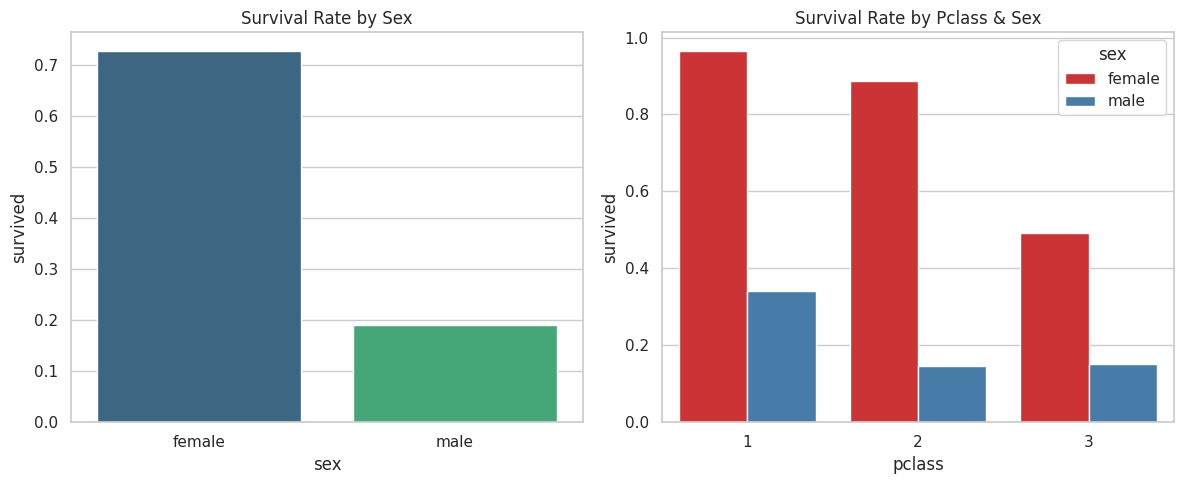

In [32]:
plt.figure(figsize=(12, 5))

# 1. Survival Rate by Gender
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='sex', y='survived', errorbar=None, hue='sex', palette='viridis', legend=False)
plt.title('Survival Rate by Sex')

# 2. Survival Rate by Class and Gender
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='pclass', y='survived', hue='sex', errorbar=None, palette='Set1')
plt.title('Survival Rate by Pclass & Sex')

plt.tight_layout()
plt.show()

In [33]:
# Rename 'sex' column to 'gender'
df = df.rename(columns={'sex': 'gender'})

# Verify the updated column names
print(df.columns)

Index(['pclass', 'survived', 'name', 'gender', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   name      1309 non-null   object 
 3   gender    1309 non-null   object 
 4   age       1309 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 92.2+ KB


**Bivariate Visualizations (Comparative Bar Charts)**

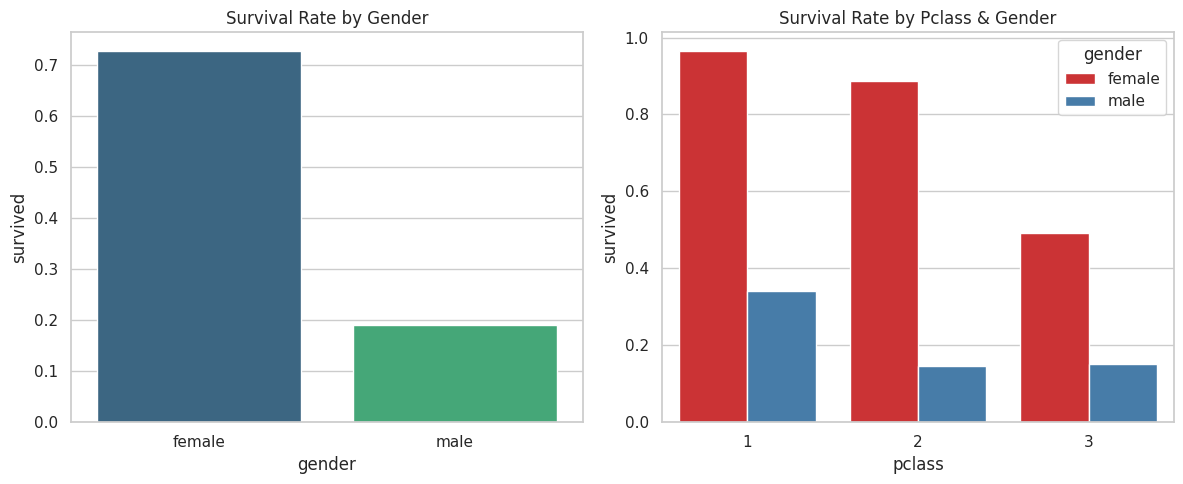

In [35]:
plt.figure(figsize=(12, 5))

# 1. Survival Rate by Gender
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='gender', y='survived', errorbar=None, hue='gender', palette='viridis', legend=False)
plt.title('Survival Rate by Gender')

# 2. Survival Rate by Class and Gender
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='pclass', y='survived', hue='gender', errorbar=None, palette='Set1')
plt.title('Survival Rate by Pclass & Gender')

plt.tight_layout()
plt.show()

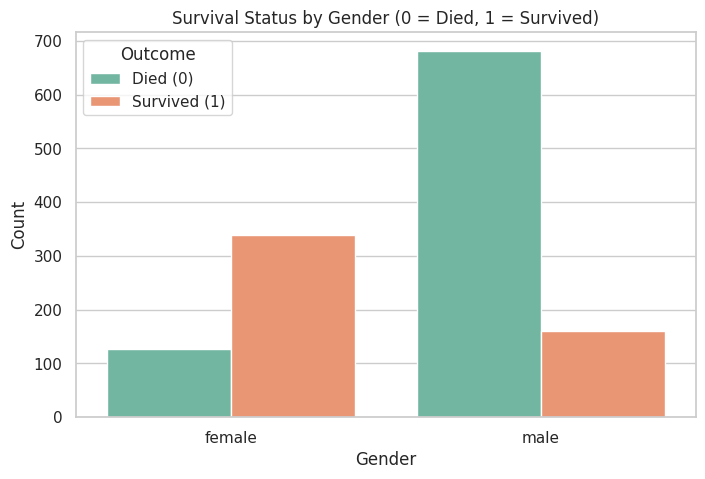

In [40]:
plt.figure(figsize=(8, 5))

# Plot count of survived vs dead categorized by gender
sns.countplot(data=df, x='gender', hue='survived', palette='Set2')

# Add details to the plot
plt.title('Survival Status by Gender (0 = Died, 1 = Survived)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['Died (0)', 'Survived (1)'])

plt.show()

**Correlation Matrix (Heatmap)**

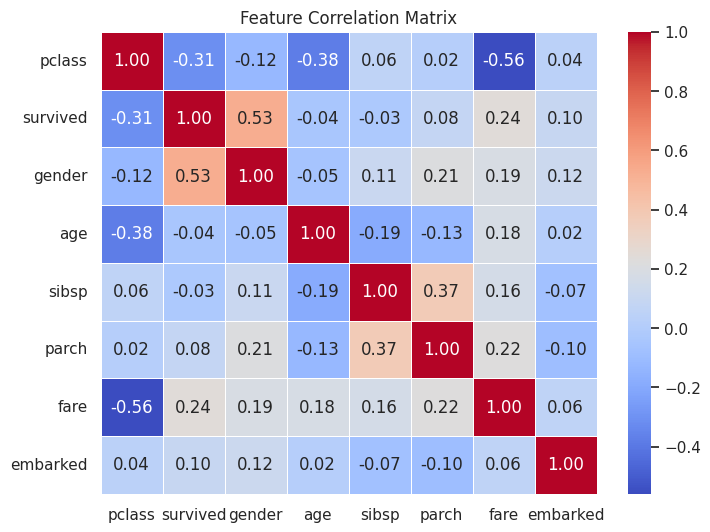

In [36]:
import numpy as np

plt.figure(figsize=(8, 6))

# Make a copy for correlation analysis
df_corr = df.copy()

# Map categorical text features to numbers
df_corr['gender'] = df_corr['gender'].map({'male': 0, 'female': 1})
df_corr['embarked'] = df_corr['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Select only numerical features for heatmap
numeric_df = df_corr.select_dtypes(include=[np.number])

# Plot Correlation Matrix
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# *Task 02 Summary & Key Insights*

**Gender Disparity:** Gender was the strongest individual factor predicting survival. Female passengers had an approximate 74% survival rate, compared to under 20% for male passengers, reflecting the "women and children first" evacuation policy.



**Socioeconomic Advantage:** Passenger class directly correlated with survival probability. 1st Class passengers (pclass = 1) achieved the highest survival rate at around 63%, while 3rd Class (pclass = 3) suffered the lowest rate at around 24%.


**Intersection of Class and Gender:** 1st Class females had the highest overall survival rate at over 95%, whereas 3rd Class males experienced the lowest survival rate at around 15%.


**Economic Correlation:** The fare feature showed a positive correlation with survival, further confirming that passengers in higher-priced accommodations had better access to lifeboats.


**Age Factor:** Children (passengers under 10 years old) showed higher relative survival rates compared to adult demographic groups across most classes.